<a href="https://colab.research.google.com/github/msbarath/Data-Science--1-24CS030-/blob/main/DS_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Food Delivery — Why Are Orders Getting Delayed?

## 1. Business Problem

This assignment focuses on analyzing food delivery data to understand the factors contributing to delivery delays and to predict delivery times. The goal is to identify operational bottlenecks and provide actionable insights to improve service efficiency and customer satisfaction.

In [ ]:
import pandas as pd

df = pd.read_csv('/content/food_delivery_assignment_dataset.csv')
display(df.head())
display(df.info())

,Order_ID,Restaurant,Area,Distance_KM,Preparation_Time,Delivery_Time,Traffic,Weather,Rider_ID,Order_Time,Peak_Hour
0,ORD000001,Tandoori House,South Zone,8.52,35.8,42.0,Medium,Cloudy,R0183,2026-06-09 00:46:00,No
1,ORD000002,Spice Hub,North Zone,1.92,13.5,30.9,High,Clear,R0112,2026-08-09 15:44:00,No
2,ORD000003,Burger Barn,West Zone,8.02,12.0,41.9,Low,Clear,R0141,2026-07-29 21:52:00,Yes
3,ORD000004,Cafe Aroma,Tech Park,3.86,14.2,41.7,Medium,Rain,R0260,2026-07-10 11:58:00,No
4,ORD000005,Biryani Express,South Zone,7.86,26.9,39.4,Medium,Clear,R0107,2026-07-09 23:18:00,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5005 entries, 0 to 5004
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          5005 non-null   object 
 1   Restaurant        5005 non-null   object 
 2   Area              5005 non-null   object 
 3   Distance_KM       5001 non-null   float64
 4   Preparation_Time  5000 non-null   float64
 5   Delivery_Time     5005 non-null   float64
 6   Traffic           4997 non-null   object 
 7   Weather           4997 non-null   object 
 8   Rider_ID          5005 non-null   object 
 9   Order_Time        5005 non-null   object 
 10  Peak_Hour         5005 non-null   object 
dtypes: float64(3), object(8)
memory usage: 430.2+ KB


None

## 2. Dataset Overview

## 3. Data Cleaning and Validation

In [ ]:
# Fill missing numerical values with median
df['Distance_KM'].fillna(df['Distance_KM'].median(), inplace=True)
df['Preparation_Time'].fillna(df['Preparation_Time'].median(), inplace=True)

# Fill missing categorical values with mode
df['Traffic'].fillna(df['Traffic'].mode()[0], inplace=True)
df['Weather'].fillna(df['Weather'].mode()[0], inplace=True)

# Convert 'Order_Time' to datetime objects
df['Order_Time'] = pd.to_datetime(df['Order_Time'])

# Convert 'Peak_Hour' to numerical (0 or 1)
df['Peak_Hour'] = df['Peak_Hour'].map({'Yes': 1, 'No': 0})

# Display updated info and check for missing values again
display(df.info())
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5005 entries, 0 to 5004
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          5005 non-null   object        
 1   Restaurant        5005 non-null   object        
 2   Area              5005 non-null   object        
 3   Distance_KM       5005 non-null   float64       
 4   Preparation_Time  5005 non-null   float64       
 5   Delivery_Time     5005 non-null   float64       
 6   Traffic           5005 non-null   object        
 7   Weather           5005 non-null   object        
 8   Rider_ID          5005 non-null   object        
 9   Order_Time        5005 non-null   datetime64[ns]
 10  Peak_Hour         5005 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(6)
memory usage: 430.2+ KB


/tmp/ipykernel_509/3394150754.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Distance_KM'].fillna(df['Distance_KM'].median(), inplace=True)
/tmp/ipykernel_509/3394150754.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

None

,0
Order_ID,0
Restaurant,0
Area,0
Distance_KM,0
Preparation_Time,0
Delivery_Time,0
Traffic,0
Weather,0
Rider_ID,0
Order_Time,0


## 4. Feature Engineering

In [ ]:
df['Order_Hour'] = df['Order_Time'].dt.hour
df['Order_Day_of_Week'] = df['Order_Time'].dt.dayofweek
# Optional: Extract month, but given the range in df.info, it might be uniform, checking first
df['Order_Month'] = df['Order_Time'].dt.month

# Display the new features
display(df[['Order_Time', 'Order_Hour', 'Order_Day_of_Week', 'Order_Month']].head())
display(df['Order_Month'].value_counts())

,Order_Time,Order_Hour,Order_Day_of_Week,Order_Month
0,2026-06-09 00:46:00,0,1,6
1,2026-08-09 15:44:00,15,6,8
2,2026-07-29 21:52:00,21,2,7
3,2026-07-10 11:58:00,11,4,7
4,2026-07-09 23:18:00,23,3,7


,count
Order_Month,
7,1701
6,1689
8,1615


## 5. Descriptive Statistics

In [ ]:
# Descriptive statistics for numerical columns
display(df.describe())

# Value counts for categorical columns
for col in ['Restaurant', 'Area', 'Traffic', 'Weather', 'Order_Day_of_Week', 'Order_Hour', 'Peak_Hour']:
    display(df[col].value_counts())

,Distance_KM,Preparation_Time,Delivery_Time,Order_Time,Peak_Hour,Order_Hour,Order_Day_of_Week,Order_Month
count,5005.000000,5005.000000,5005.000000,5005,5005.000000,5005.000000,5005.000000,5005.000000
mean,5.607273,19.216743,39.345235,2026-07-15 21:05:54.449550592,0.242757,11.521878,3.007992,6.985215
min,1.000000,5.000000,8.000000,2026-06-01 01:07:00,0.000000,0.000000,0.000000,6.000000
25%,3.250000,14.700000,29.800000,2026-06-23 06:05:00,0.000000,6.000000,1.000000,6.000000
50%,4.970000,18.700000,38.000000,2026-07-15 11:10:00,0.000000,11.000000,3.000000,7.000000
75%,7.210000,23.500000,47.600000,2026-08-07 15:50:00,0.000000,18.000000,5.000000,8.000000
max,45.000000,90.000000,180.000000,2026-08-29 23:29:00,1.000000,23.000000,6.000000,8.000000
std,3.229044,6.194111,13.381244,NaN,0.428792,6.891080,1.992576,0.812437


,count
Restaurant,
Food Factory,448
Green Bowl,444
South Corner,440
Tandoori House,438
Cafe Aroma,417
Spice Hub,416
Burger Barn,415
Urban Bites,414
Biryani Express,410


,count
Area,
South Zone,661
West Zone,657
Central,638
Tech Park,625
Residential,618
North Zone,606
East Zone,602
Market Area,598


,count
Traffic,
Medium,1782
Low,1397
High,1280
Jam,546


,count
Weather,
Clear,2860
Cloudy,1136
Rain,812
Storm,197


,count
Order_Day_of_Week,
5,750
2,740
4,727
0,714
3,694
6,691
1,689


,count
Order_Hour,
6,232
16,229
11,226
10,225
19,224
3,223
7,219
23,216
18,215


,count
Peak_Hour,
0,3790
1,1215


## 6. Exploratory Data Analysis

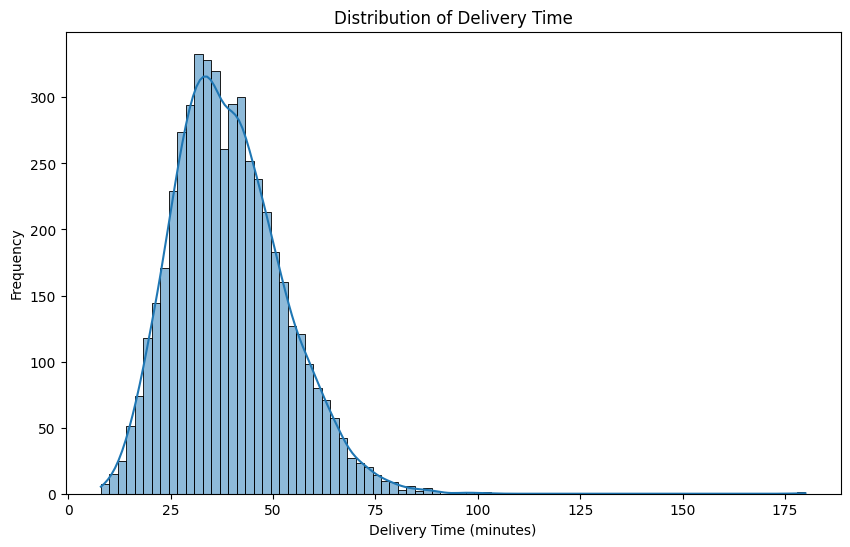

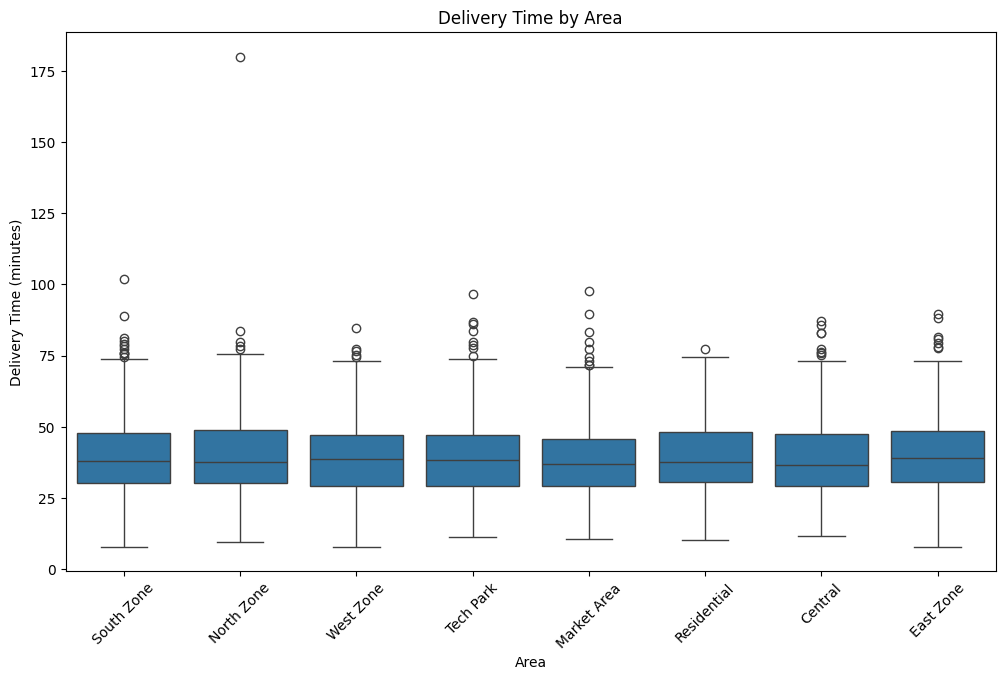

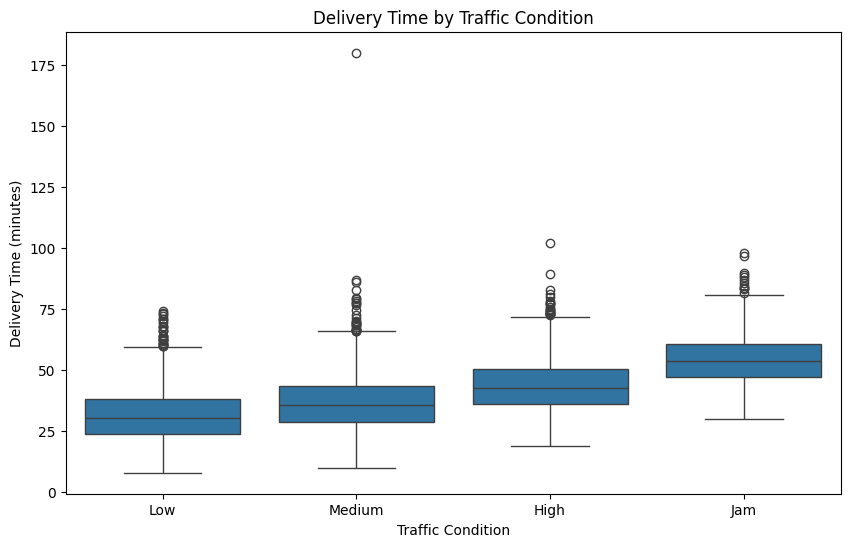

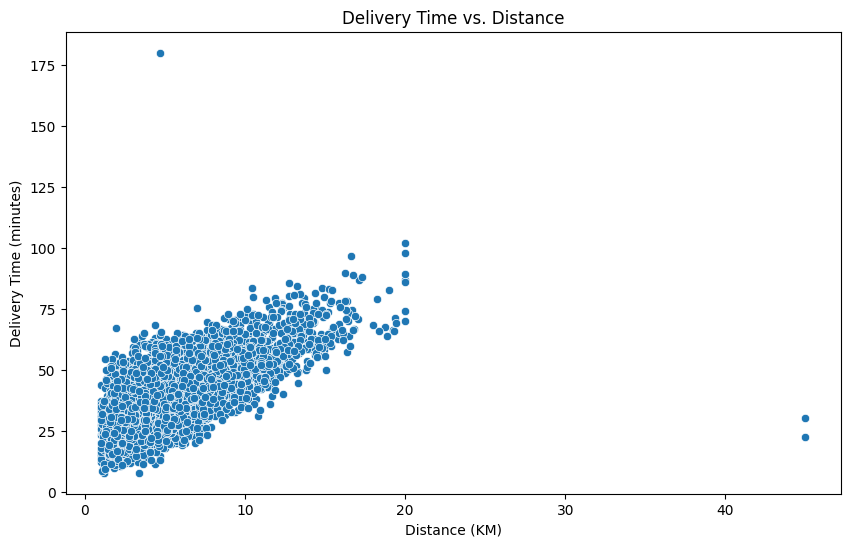

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Delivery_Time'], kde=True)
plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(12, 7))
sns.boxplot(x='Area', y='Delivery_Time', data=df)
plt.title('Delivery Time by Area')
plt.xlabel('Area')
plt.ylabel('Delivery Time (minutes)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Traffic', y='Delivery_Time', data=df, order=['Low', 'Medium', 'High', 'Jam'])
plt.title('Delivery Time by Traffic Condition')
plt.xlabel('Traffic Condition')
plt.ylabel('Delivery Time (minutes)')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Distance_KM', y='Delivery_Time', data=df)
plt.title('Delivery Time vs. Distance')
plt.xlabel('Distance (KM)')
plt.ylabel('Delivery Time (minutes)')
plt.show()

## 7. Operational Hotspots

,Delivery_Time
Area,
East Zone,40.074419
North Zone,39.978053
South Zone,39.721634
Residential,39.620227
West Zone,39.314003
Tech Park,38.883040
Central,38.744201
Market Area,38.428261


,Delivery_Time
Restaurant,
Tandoori House,40.692694
Biryani Express,39.960000
Burger Barn,39.766265
Cafe Aroma,39.540048
Green Bowl,39.502252


,Delivery_Time
Restaurant,
Spice Hub,39.254327
Urban Bites,38.781159
Royal Meals,38.697368
Pizza Point,38.530789
South Corner,38.393182


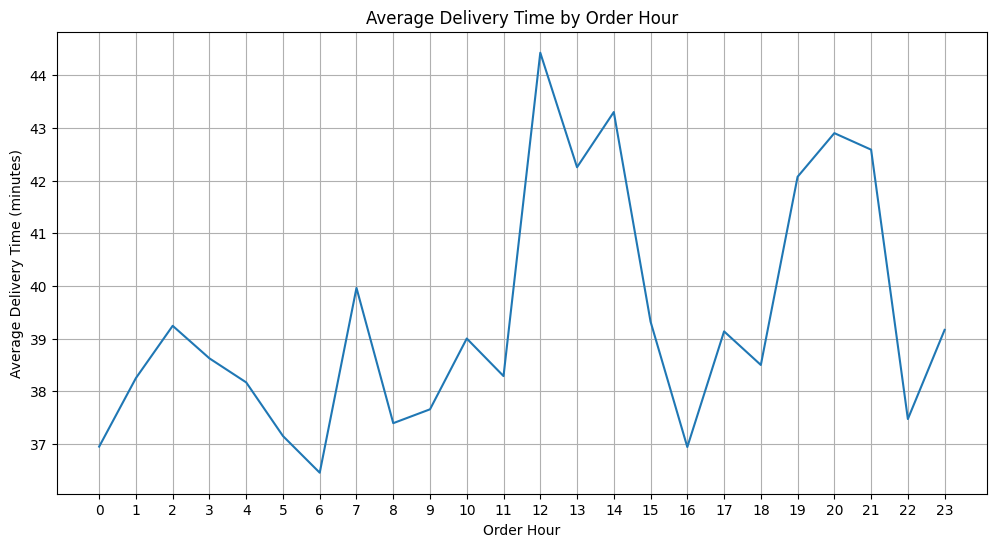

Weather,Clear,Cloudy,Rain,Storm
Traffic,,,,
High,41.951093,44.018212,50.080749,53.576271
Jam,52.962658,55.593496,57.665823,59.589286
Low,29.967459,31.357460,37.683621,38.862745
Medium,35.499605,35.900758,41.784076,46.654237


In [ ]:
# Average Delivery Time by Area
avg_delivery_by_area = df.groupby('Area')['Delivery_Time'].mean().sort_values(ascending=False)
display(avg_delivery_by_area)

# Average Delivery Time by Restaurant (Top 5 and Bottom 5)
avg_delivery_by_restaurant = df.groupby('Restaurant')['Delivery_Time'].mean().sort_values(ascending=False)
display(avg_delivery_by_restaurant.head())
display(avg_delivery_by_restaurant.tail())

# Average Delivery Time by Order Hour
avg_delivery_by_hour = df.groupby('Order_Hour')['Delivery_Time'].mean()
plt.figure(figsize=(12, 6))
sns.lineplot(x=avg_delivery_by_hour.index, y=avg_delivery_by_hour.values)
plt.title('Average Delivery Time by Order Hour')
plt.xlabel('Order Hour')
plt.ylabel('Average Delivery Time (minutes)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

# Average Delivery Time by Traffic and Weather
avg_delivery_traffic_weather = df.groupby(['Traffic', 'Weather'])['Delivery_Time'].mean().unstack()
display(avg_delivery_traffic_weather)

## 8. Random Forest Model

## 9. Model Evaluation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define target and features
X = df.drop(['Delivery_Time', 'Order_ID', 'Rider_ID', 'Order_Time'], axis=1)
y = df['Delivery_Time']

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create a pipeline with preprocessing and RandomForestRegressor
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model_pipeline.fit(X_train, y_train)

display("Random Forest Model training complete.")

'Random Forest Model training complete.'

## 10. Feature Importance

## 10. Feature Importance

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R²): {r2:.2f}')

Mean Absolute Error (MAE): 4.45
Root Mean Squared Error (RMSE): 5.61
R-squared (R²): 0.82


,feature,importance
0,Distance_KM,0.558884
24,Traffic_Jam,0.150248
23,Traffic_High,0.073571
1,Preparation_Time,0.038482
2,Peak_Hour,0.022232
25,Traffic_Low,0.019477
27,Weather_Clear,0.016848
29,Weather_Rain,0.015165
30,Weather_Storm,0.014289
26,Traffic_Medium,0.014128


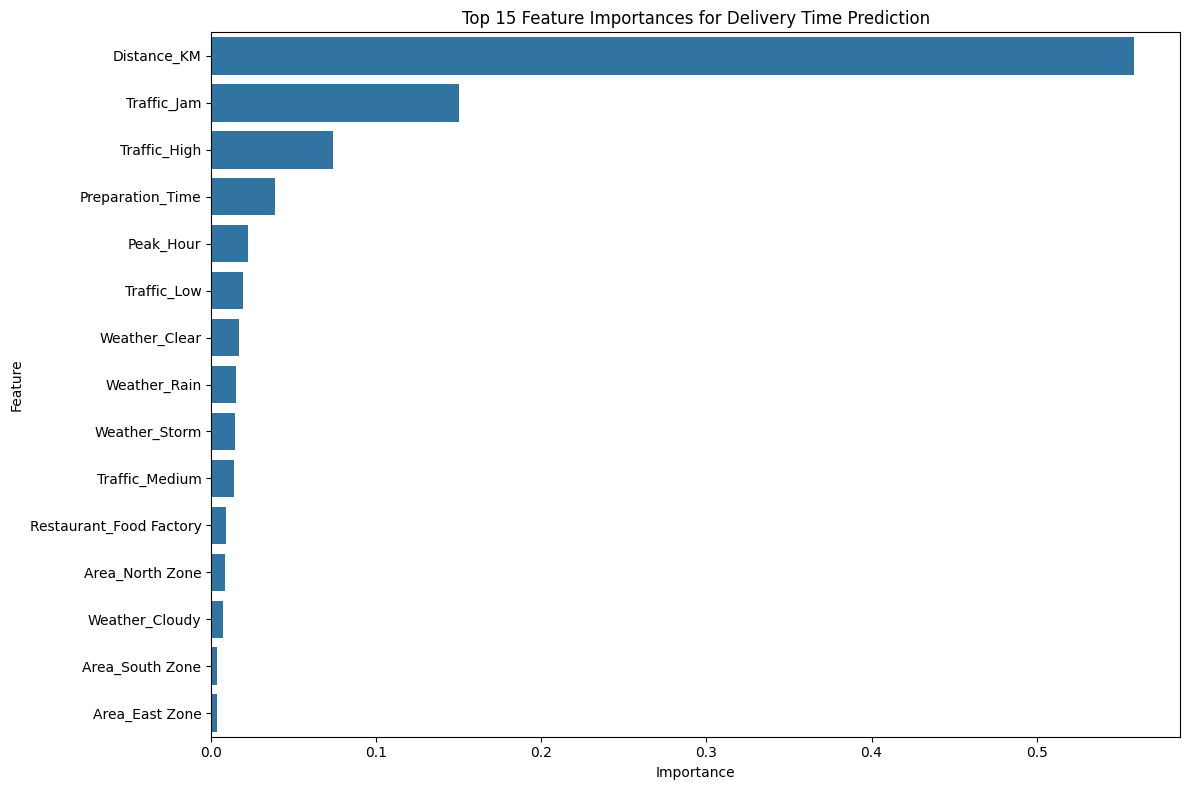

In [ ]:
# Extract feature importances from the trained Random Forest model
# Get feature names after one-hot encoding
preprocessor = model_pipeline.named_steps['preprocessor']

# Get one-hot encoded feature names
onehot_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

# Combine numerical and one-hot encoded feature names
all_features = list(numerical_features) + list(onehot_features)

# Get feature importances from the regressor
importances = model_pipeline.named_steps['regressor'].feature_importances_

# Create a DataFrame for feature importances
feature_importances = pd.DataFrame({
    'feature': all_features,
    'importance': importances
})

# Sort by importance
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

# Display top 10 features
display(feature_importances.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances.head(15))
plt.title('Top 15 Feature Importances for Delivery Time Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 11. Key Insights

Based on the comprehensive data analysis and the Random Forest model's findings, the following key insights have been identified regarding food delivery times:

1.  **Distance is the Primary Driver of Delivery Time**: `Distance_KM` is by far the most influential factor, with a feature importance of approximately **0.56**. This indicates that the physical distance between the restaurant and the delivery location is the paramount determinant of how long an order takes to deliver.

2.  **Traffic Conditions are Critical Bottlenecks**: Severe traffic conditions significantly impede delivery. `Traffic_Jam` and `Traffic_High` are the next most important features, with importances of approximately **0.15** and **0.07** respectively. Deliveries during 'Jam' traffic, especially when combined with adverse weather, can take up to **59.59 minutes** (Traffic_Jam, Weather_Storm), significantly higher than typical delivery times.

3.  **Preparation Time Directly Impacts Delivery Speed**: The `Preparation_Time` at the restaurant is a substantial factor, showing a feature importance of about **0.038**. Efficient kitchen operations and quicker food preparation are crucial for reducing overall delivery times.

4.  **Peak Hours Experience Longer Deliveries**: Orders placed during `Peak_Hour` (feature importance ~**0.022**) tend to have extended delivery times. This is likely due to increased order volume and potentially higher traffic congestion during these periods, as observed in the average delivery times peaking around lunch and dinner hours.

5.  **Adverse Weather Conditions Lead to Delays**: Inclement weather, including `Weather_Rain` (importance ~**0.015**) and `Weather_Storm` (importance ~**0.014**), consistently increases delivery durations. For instance, 'High' traffic with 'Rain' results in an average delivery time of **50.08 minutes**, compared to **41.95 minutes** under 'High' traffic and 'Clear' weather.

6.  **Variations in Delivery Performance Across Areas and Restaurants**: While individual areas and restaurants might not feature as top individual predictors due to one-hot encoding, there are notable differences in average delivery times. For example, the **East Zone** has the highest average delivery time at **40.07 minutes**, while **Tandoori House** has the highest average delivery time among restaurants at **40.69 minutes**. These localized variations suggest potential operational inefficiencies or unique challenges specific to these entities.

## 12. Practical Action Plan

Based on the identified key insights, here is a practical action plan to mitigate delivery delays and optimize the food delivery service:

1.  **Optimize Route Planning for Distance Management**: Since `Distance_KM` is the most significant factor, invest in advanced real-time route optimization software that considers current traffic conditions and distance. Implement algorithms that prioritize assigning orders to the nearest available riders. Explore options for micro-warehousing or ghost kitchens in high-demand, distant areas to reduce average delivery distances.

2.  **Proactive Traffic Management Strategies**: Develop a predictive model for traffic congestion using historical traffic data, real-time updates, and weather forecasts. During anticipated `Traffic_Jam` or `Traffic_High` periods, automatically adjust estimated delivery times, increase rider availability in affected areas, and consider dynamic pricing to encourage orders during off-peak hours or adjust rider compensation for challenging conditions.

3.  **Streamline Restaurant Preparation Processes**: Collaborate with restaurants, especially those with historically higher `Preparation_Time` or average delivery times (e.g., Tandoori House), to identify bottlenecks in their kitchen operations. Offer best practices for order management, kitchen layout optimization, and staff training. Provide real-time feedback to restaurants on their preparation times and their impact on delivery metrics.

4.  **Manage Peak Hour Demand**: Implement strategies to manage the surge in orders during `Peak_Hour`s. This could include flexible rider scheduling to ensure maximum coverage during lunch and dinner rushes, offering incentives for riders to work during peak times, and potentially staggering order acceptance at restaurants to prevent overwhelming them.

5.  **Develop Weather-Contingency Plans**: Establish clear protocols for adverse `Weather_Rain` and `Weather_Storm` conditions. This includes increasing rider availability, providing weather-appropriate gear, adjusting delivery zones, communicating transparently with customers about potential delays, and implementing surge pricing for riders during harsh weather to maintain service levels.

6.  **Targeted Operational Improvements for Specific Areas and Restaurants**: Conduct deeper dives into underperforming areas (e.g., East Zone) and restaurants (e.g., Tandoori House) to identify specific operational challenges. This might involve assessing rider density, route efficiency, restaurant preparedness, and local infrastructure. Develop tailored solutions for these hotspots, such as dedicated support teams or specific training programs.

## 13. Conclusion

This analysis successfully identified the primary factors influencing food delivery times and developed a predictive model to estimate them. Distance, traffic conditions, and preparation time emerged as the most critical determinants. The Random Forest model achieved a commendable R-squared of **0.82**, indicating its strong predictive capability. Based on these findings, a targeted action plan was proposed to optimize route planning, manage traffic and peak hour challenges, streamline restaurant operations, and establish weather contingency protocols. Implementing these recommendations should significantly enhance delivery efficiency, improve customer satisfaction, and contribute to the overall operational excellence of the food delivery service.